In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/My Drive/Spring25_Semester/IS_296/IS296_Collab/PI

/content/drive/My Drive/Spring25_Semester/IS_296/IS296_Collab/PI


In [5]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [6]:
tbl = Table.read_table('/content/drive/My Drive/Spring25_Semester/IS_296/IS296_Collab/PI/BHuynh_Personal_Informatics.csv')
tbl

WeekID,day ID,DayOfWeek,date,Time Exercising (Min),Time Studying (Min),"Emotion (0 = low, 1 = med, 2 = high)",Time Reading (Min),"Sleep (Over 8 hours = 1, Under 8 hours = 0)",Number of Diary Entries
0,1,Mon,2/10/2025,32,150,0,29,0,0
0,2,Tue,2/11/2025,82,90,1,30,1,0
0,3,Wed,2/12/2025,24,30,1,20,1,1
0,4,Thu,2/13/2025,115,30,2,5,1,0
0,5,Fri,2/14/2025,0,0,0,0,0,0
0,6,Sat,2/15/2025,0,0,2,0,1,0
0,7,Sun,2/16/2025,21,90,1,0,1,0
1,8,Mon,2/17/2025,53,200,2,0,1,1
1,9,Tue,2/18/2025,46,30,1,30,1,0
1,10,Wed,2/19/2025,112,45,0,0,0,0


sample mean= 36.2142857143


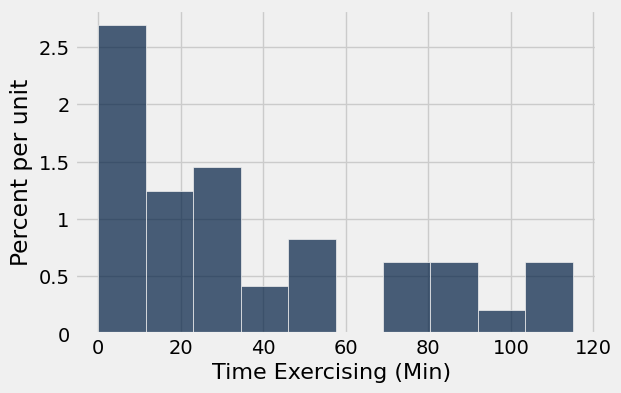

In [22]:
tbl.hist('Time Exercising (Min) ')
my_variable = tbl.column('Time Exercising (Min) ')
my_estimate = np.mean(my_variable)  # update
print ('sample mean=',my_estimate) # update

In [23]:
def one_bootstrap():
    single_sample = tbl.sample()
    return np.mean(single_sample.column('Time Exercising (Min) '))

In [24]:
one_bootstrap()

40.142857142857146

In [25]:
bootstrap_result = make_array()
for i in np.arange(1000):
    new_estimate = one_bootstrap()
    bootstrap_result = np.append(bootstrap_result, new_estimate)
bootstrap_result

array([ 29.45238095,  33.88095238,  38.5952381 ,  44.95238095,
        27.69047619,  35.47619048,  30.88095238,  36.95238095,
        36.97619048,  30.42857143,  38.52380952,  28.47619048,
        45.71428571,  40.26190476,  33.19047619,  43.0952381 ,
        45.42857143,  42.35714286,  38.66666667,  38.38095238,
        44.33333333,  42.42857143,  37.92857143,  41.52380952,
        31.78571429,  36.92857143,  48.21428571,  32.5       ,
        34.5       ,  31.80952381,  42.33333333,  35.64285714,
        27.73809524,  35.64285714,  43.42857143,  33.07142857,
        42.02380952,  43.64285714,  27.4047619 ,  37.9047619 ,
        35.30952381,  32.9047619 ,  28.28571429,  35.04761905,
        38.28571429,  34.71428571,  37.73809524,  42.61904762,
        35.71428571,  36.97619048,  38.71428571,  24.11904762,
        30.52380952,  36.97619048,  33.52380952,  32.42857143,
        31.35714286,  34.5952381 ,  46.04761905,  32.42857143,
        44.28571429,  35.69047619,  23.83333333,  30.  

In [26]:
#95% Confidence Interval
print('95% Confidence Interval of Sample Mean')
percentile(2.5, bootstrap_result), percentile(97.5, bootstrap_result)

95% Confidence Interval of Sample Mean


(26.142857142857142, 47.285714285714285)

In [27]:
sample_mean = np.mean(tbl.column('Time Exercising (Min) '))
sample_size = tbl.num_rows
sample_std = np.std(tbl.column('Time Exercising (Min) '))

stderr = sample_std/np.sqrt(sample_size)
upper_CI = sample_mean + 1.96 * stderr
lower_CI = sample_mean - 1.96 * stderr
print('95% Confidence Interval of Sample Mean')
lower_CI, upper_CI

95% Confidence Interval of Sample Mean


(25.559653961954819, 46.868917466616608)

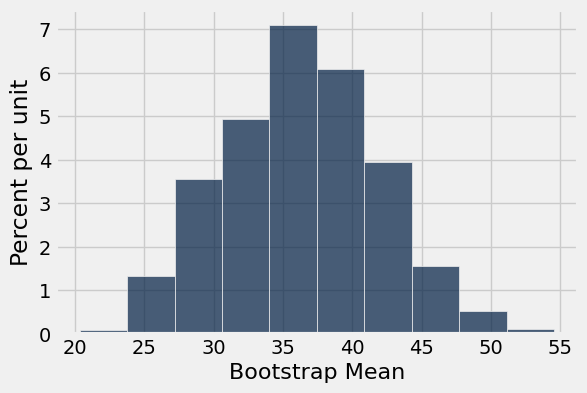

In [28]:
Table().with_column('Bootstrap Mean', bootstrap_result).hist('Bootstrap Mean')